# AI4I Machine-Failure Dataset Exploration

This notebook loads and explores the UCI AI4I 2020 Predictive Maintenance Dataset.

## Objectives

- Load the official dataset
- Understand the available features
- Examine the machine-failure target
- Check for missing values
- Measure class imbalance
- Visualize important feature distributions

In [1]:
# Data handling
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Download the official UCI dataset
from ucimlrepo import fetch_ucirepo

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Download the official AI4I 2020 Predictive Maintenance Dataset
ai4i = fetch_ucirepo(id=601)

# Separate input features and target variables
X = ai4i.data.features.copy()
y = ai4i.data.targets.copy()

# Combine features and targets into one table
df = pd.concat([X, y], axis=1)

print("Dataset downloaded successfully.")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Display the first five records
df.head()

Dataset downloaded successfully.
Number of rows: 10000
Number of columns: 12


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# Download the official AI4I 2020 dataset
ai4i = fetch_ucirepo(id=601)

# Obtain the machine measurements and failure targets
X = ai4i.data.features.copy()
y = ai4i.data.targets.copy()

# Combine them into one dataset
df = pd.concat([X, y], axis=1)

print("Dataset downloaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset downloaded successfully.
Dataset shape: (10000, 12)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. Initial Data Inspection

This section examines the dataset dimensions, column types, unique values, and missing measurements.

In [4]:
print(f"Dataset rows: {df.shape[0]}")
print(f"Dataset columns: {df.shape[1]}")

column_summary = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Unique values": df.nunique(),
    "Missing values": df.isna().sum()
})

column_summary

Dataset rows: 10000
Dataset columns: 12


,Data type,Unique values,Missing values
Type,str,3,0
Air temperature,float64,93,0
Process temperature,float64,82,0
Rotational speed,int64,941,0
Torque,float64,577,0
Tool wear,int64,246,0
Machine failure,int64,2,0
TWF,int64,2,0
HDF,int64,2,0
PWF,int64,2,0


## 2. Target-Class Distribution

The distribution of the machine-failure target is examined to determine the severity of class imbalance.

In [5]:
# Count each target class
target_counts = df["Machine failure"].value_counts().sort_index()

# Calculate class percentages
target_percentages = (
    df["Machine failure"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

class_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

# Replace numerical labels with understandable names
class_distribution.index = ["No failure (0)", "Failure (1)"]

class_distribution

,Count,Percentage
No failure (0),9661,96.61
Failure (1),339,3.39


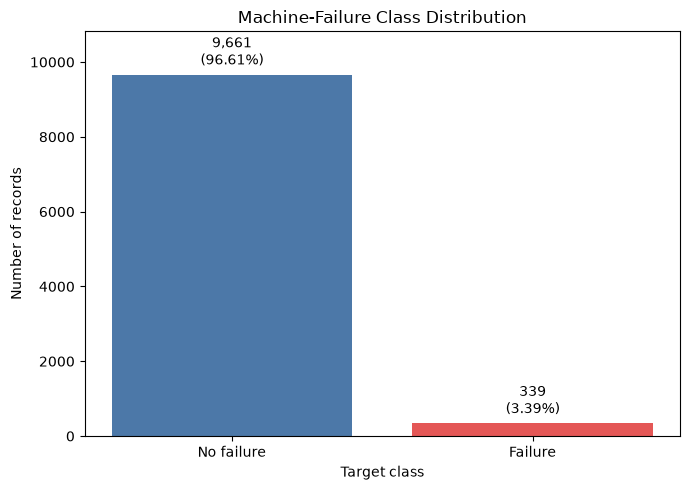

Figure saved to: c:\Users\aacaa\Documents\reliable-machine-failure-prediction\figures\class_distribution.png


In [6]:
from pathlib import Path

# Create the bar chart
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["No failure", "Failure"],
    target_counts.values,
    color=["#4C78A8", "#E45756"]
)

# Display count and percentage above each bar
labels = [
    f"{count:,}\n({percentage:.2f}%)"
    for count, percentage in zip(
        target_counts.values,
        target_percentages.values
    )
]

ax.bar_label(bars, labels=labels, padding=4)

ax.set_title("Machine-Failure Class Distribution")
ax.set_xlabel("Target class")
ax.set_ylabel("Number of records")
ax.set_ylim(0, target_counts.max() * 1.12)

plt.tight_layout()

# Find the project folder and save the figure
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

figure_path = project_root / "figures" / "class_distribution.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

## 3. Class-Imbalance Visualization

The target distribution is visualized to show the difference between normal and failed machine records.

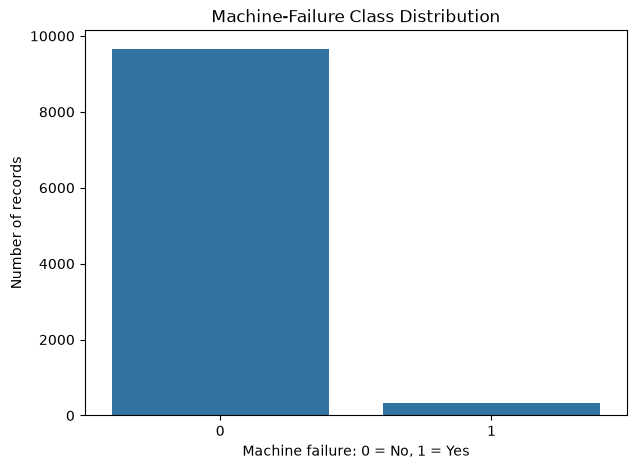

In [7]:
# Create an empty figure
plt.figure(figsize=(7, 5))

# Count classes 0 and 1 and draw their bars
sns.countplot(
    data=df,
    x="Machine failure"
)

# Add descriptions
plt.title("Machine-Failure Class Distribution")
plt.xlabel("Machine failure: 0 = No, 1 = Yes")
plt.ylabel("Number of records")

# Display the completed graph
plt.show()

## 4. Numerical Feature Summary

Descriptive statistics are calculated for the numerical machine measurements to understand their ranges, central values, and variability.

In [9]:
# Select only the numerical input features
numeric_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

# Calculate descriptive statistics
numeric_summary = (
    df[numeric_features]
    .describe()
    .T
    .round(2)
)

numeric_summary

,count,mean,std,min,25%,50%,75%,max
Air temperature,10000.0,300.00,2.00,295.3,298.3,300.1,301.5,304.5
Process temperature,10000.0,310.01,1.48,305.7,308.8,310.1,311.1,313.8
Rotational speed,10000.0,1538.78,179.28,1168.0,1423.0,1503.0,1612.0,2886.0
Torque,10000.0,39.99,9.97,3.8,33.2,40.1,46.8,76.6
Tool wear,10000.0,107.95,63.65,0.0,53.0,108.0,162.0,253.0


## 5. Failure Rate by Machine Type

The number and percentage of machine failures are compared across the L, M, and H product types.

In [10]:
# Group records by machine type and calculate failure information
type_analysis = df.groupby("Type")["Machine failure"].agg(
    Total_records="count",
    Failure_count="sum",
    Failure_rate="mean"
)

# Convert failure rate from a proportion to a percentage
type_analysis["Failure_rate"] = (
    type_analysis["Failure_rate"] * 100
).round(2)

# Give the percentage column a clearer name
type_analysis = type_analysis.rename(
    columns={"Failure_rate": "Failure rate (%)"}
)

type_analysis

,Total_records,Failure_count,Failure rate (%)
Type,,,
H,1003,21,2.09
L,6000,235,3.92
M,2997,83,2.77


## 6. Numerical Feature Distributions

Histograms are used to examine the distributions, ranges, and potential extreme values of the numerical input features.